In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [3]:
#defining the path
data_dir = Path("/Users/folasewaabdulsalam/Downloads/EEG_Based_Mental_Workload_Classifier/EEG-Based_Mental_Workload_Classifier/data")


In [4]:
#checking the structure of one text file
test_file = data_dir/'sub01_hi.txt'
sample_data = np.loadtxt(test_file)

print(f'The shape of the data is:{sample_data.shape}')
print(f'The data type is: {sample_data.dtype}')
print(f'\nThe first five rows and channels are:')
print(sample_data[:5, :5])

The shape of the data is:(19200, 14)
The data type is: float64

The first five rows and channels are:
[[4584.62 3902.05 4571.79 4589.23 4124.62]
 [4584.1  3895.9  4574.87 4567.69 4124.1 ]
 [4574.36 3893.85 4576.92 4572.82 4123.59]
 [4573.85 3906.15 4572.82 4612.31 4137.95]
 [4583.59 3911.28 4570.26 4621.03 4150.77]]


In [5]:
#defining the channel names with the Emotiv EPOC EEG channel names
channel_name = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

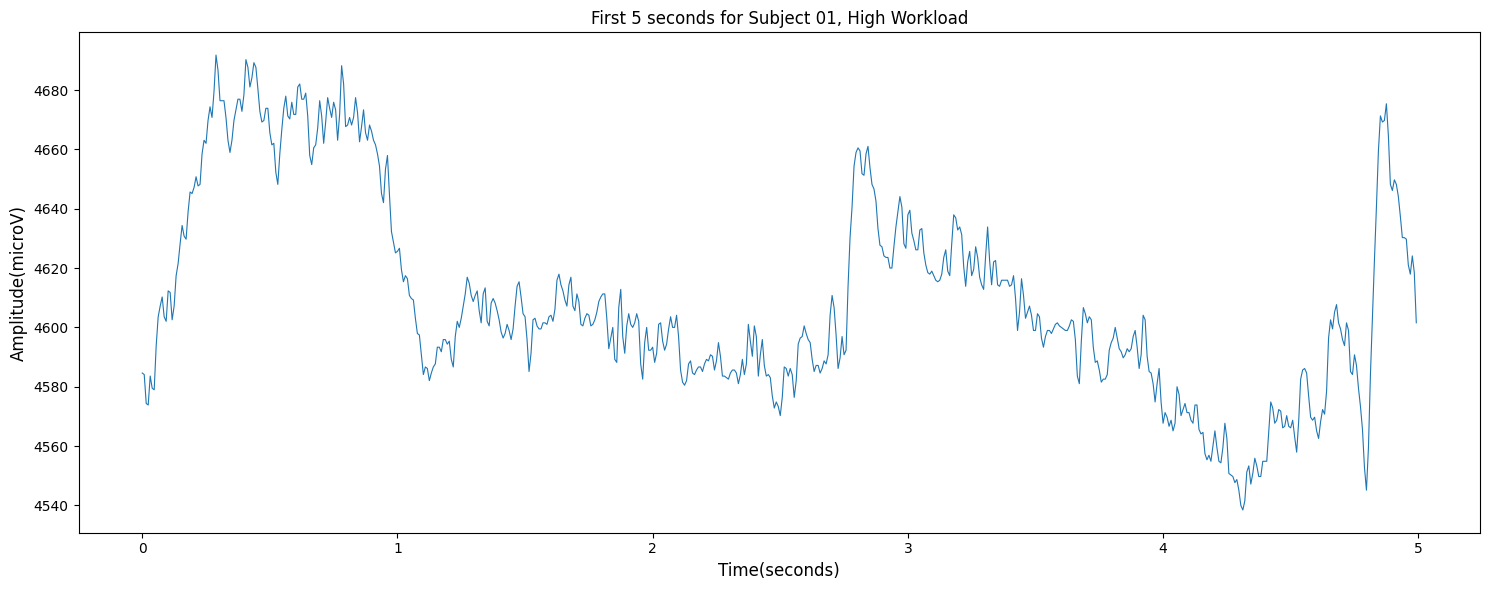

In [6]:
#visualizing the first 5 seconds of a channel
sampling_frequency = 128
duration = 5
no_of_samples = sampling_frequency * duration

time = np.arange(no_of_samples)/sampling_frequency

#plotting the first 5 seconds of the first channel
plt.figure(figsize= (15, 6))
plt.plot(time, sample_data[:no_of_samples,0], linewidth = 0.8)
plt.xlabel("Time(seconds)", fontsize=12)
plt.ylabel("Amplitude(microV)", fontsize=12)
plt.title("First 5 seconds for Subject 01, High Workload")
plt.tight_layout()
plt.show()




In [9]:
#extracting the subject id, and workload from the file names

all_data = []
all_subjects = []
all_workloads = []

for file in sorted(data_dir.glob("*.txt")):
    filename = file.stem
    parts = filename.split('_')
    subjects = parts[0]
    workload = parts[1]

    eeg_data = np.loadtxt(file)
    all_data.append(eeg_data)
    all_subjects.append(subjects)
    all_workloads.append(workload)

print(f"loaded {len(all_data)} files")
print(f"First five subjects are: {all_subjects[:5]}")
print(f"First five workloads are: {all_workloads[:5]}")


loaded 96 files
First five subjects are: ['sub01', 'sub01', 'sub02', 'sub02', 'sub03']
First five workloads are: ['hi', 'lo', 'hi', 'lo', 'hi']


In [11]:
#confirming if the files have the same duration

#checking the duration of each file
durations = []
for data in all_data:
    num_of_samples = data.shape[0]
    duration_seconds = num_of_samples / sampling_frequency
    durations.append(duration_seconds)
print(f"All the same duration? {len(set(durations))==1}")
print(f"recordings are {durations[0]} seconds long")

All the same duration? True
recordings are 150.0 seconds long


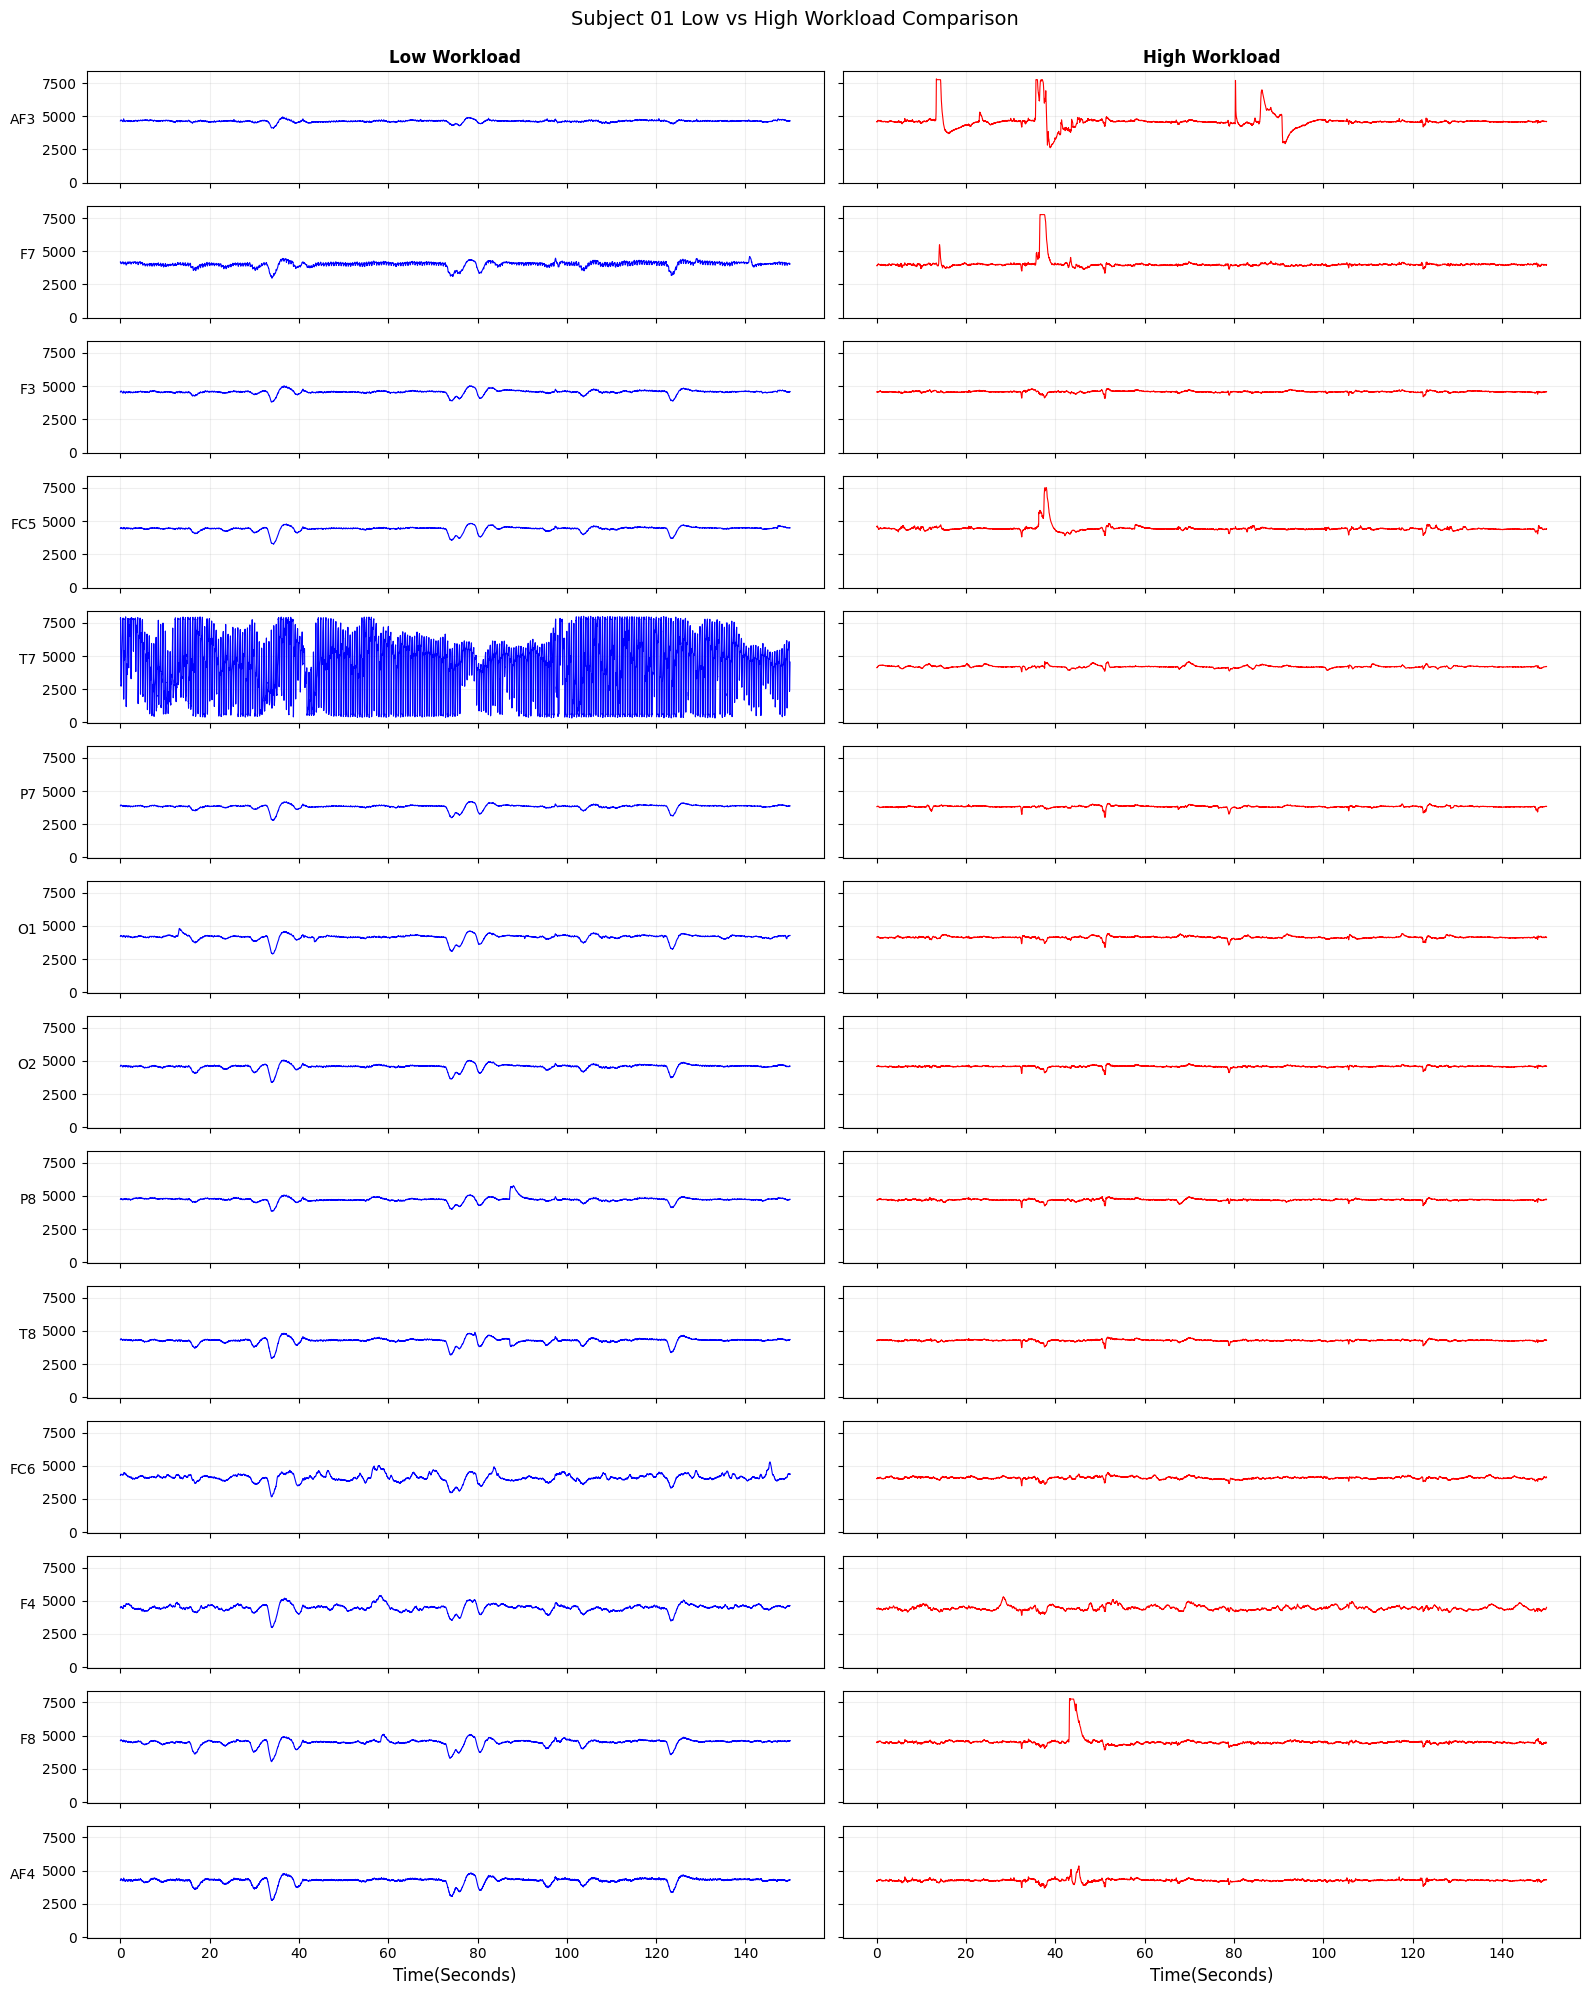

In [16]:
#visually comparing low vs high workload signals

#subject 01 low vs high
sub01_lo_idx = None
sub01_hi_idx = None

for i in range(len(all_subjects)):
    if all_subjects[i] == 'sub01' and all_workloads[i] == "lo":
        sub01_lo_idx = i
    if all_subjects[i] == 'sub01' and all_workloads[i] == 'hi':
        sub01_hi_idx = i
sub01_lo = all_data[sub01_lo_idx]
sub01_hi = all_data[sub01_hi_idx]

#plotting the first 150 seconds
duration = 150
samples = duration * sampling_frequency
time = np.arange(samples) / sampling_frequency

fig,axes = plt.subplots(14, 2, figsize = (16,20), sharex=True, sharey=True)

for i, channel in enumerate(channel_name):
    axes[i, 0].plot(time, sub01_lo[:samples,i], linewidth = 0.8, color='blue')
    axes[i, 0].set_ylabel(channel, fontsize=10, rotation=0, ha='right')
    axes[i, 0].grid(alpha=0.2)

    axes[i, 1].plot(time, sub01_hi[:samples, i], linewidth = 0.8, color='red')
    axes[i, 1].grid(alpha=0.2)

axes[0, 0].set_title("Low Workload", fontsize = 12, fontweight = 'bold')
axes[0, 1].set_title("High Workload", fontsize = 12, fontweight = 'bold')
axes[-1, 0].set_xlabel("Time(Seconds)", fontsize=12)
axes[-1, 1].set_xlabel("Time(Seconds)", fontsize=12)
fig.suptitle('Subject 01 Low vs High Workload Comparison', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

## Summary of Exploration

- **Dataset:** 96 files (48 subjects × 2 conditions: high/low workload)
- **Duration:** 150 seconds per recording
- **Sampling rate:** 128 Hz  
- **Channels:** 14 (Emotiv EPOC, 10-20 system)
- **Data format:** Raw EEG in µV, space-separated text files

**Observations:**
- Raw, unfiltered signals with visible artifacts (especially T7 in Subject 01 low workload)
- High workload shows spike artifacts in frontal channels (AF3, F7, FC5, F8)
- Data requires preprocessing before feature extraction
- No obvious visual difference in frequency content between conditions (requires spectral analysis)

**Next steps:**
- High-pass filter at 1 Hz
- Remove line noise (50/60 Hz notch)
- Artifact Subspace Reconstruction (ASR)
- Re-reference to average